In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install requests
#used to download datasets (like CIFAR-10H)

In [5]:
PROJECT = '/content/drive/MyDrive/cifar10h_project'

import os
print("Project folder contents:", os.listdir(PROJECT))


Project folder contents: ['data', 'checkpoints', 'results', 'code']


In [6]:
# CELL 2 — Check versions of key libraries


import torch
import torchvision
import numpy as np
import matplotlib
import scipy
import seaborn

print(f"PyTorch      : {torch.__version__}")
print(f"Torchvision  : {torchvision.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"Scipy        : {scipy.__version__}")
print(f"Seaborn      : {seaborn.__version__}")

# Check if GPU is available
print(f"\nGPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")

PyTorch      : 2.10.0+cu128
Torchvision  : 0.25.0+cu128
NumPy        : 2.0.2
Matplotlib   : 3.10.0
Scipy        : 1.16.3
Seaborn      : 0.13.2

GPU available: True
GPU name     : Tesla T4


In [7]:
# CELL 3 — All imports
# We import everything at the top of the notebook

import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import entropy as scipy_entropy  # for computing Shannon entropy,  as we need to calculate true entropy from CIFAR-10H ditribution

import torch #our entire model of CNN , will be build by torch.nn, loss functions, optimizers everything
import torchvision # loading the CIFAR-10
import torchvision.transforms as transforms # far-10 images, we need to normalize them and apply augmentations like random flips
from torch.utils.data import Subset #this helps in split of far-10H into train, val, test sets

# Fix random seeds RIGHT NOW.
# so that the 6k/2k/2k split is always identical.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All imports successful.")
print(f"Random seed set to: {SEED}")

All imports successful.
Random seed set to: 42


In [8]:

# CELL 4 — Define all file paths
# We define every path in one place.
# All data goes into the 'data' subfolder of your project.

PROJECT = '/content/drive/MyDrive/cifar10h_project'

# Subfolder paths
DATA_DIR        = os.path.join(PROJECT, 'data') #os.path.join() makes paths OS-independednt
CHECKPOINTS_DIR = os.path.join(PROJECT, 'checkpoints') # this saves model weights during training, so we can resume or pick best model
RESULTS_DIR     = os.path.join(PROJECT, 'results')  # save plots, entropy predictions, failure case images

# CIFAR-10 will be downloaded into a subfolder called 'cifar10'
CIFAR10_DIR     = os.path.join(DATA_DIR, 'cifar10')

# CIFAR-10H soft labels file
CIFAR10H_PATH   = os.path.join(DATA_DIR, 'cifar10h-probs.npy')

# Where we'll save the split indices
SPLIT_PATH      = os.path.join(DATA_DIR, 'split_indices.npz') # will save which images go to train/valid/test, so we can use the same split everytime

# Where we'll save the entropy array
ENTROPY_PATH    = os.path.join(DATA_DIR, 'entropies.npy') #will cache precomputed true entropy values

# Create any directories that don't exist yet
# exist_ok=True means it won't crash if they already exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CIFAR10_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("All paths defined and directories confirmed:")
print(f"  DATA_DIR        : {DATA_DIR}")  # it holds all data far10 and far10H
print(f"  CIFAR10_DIR     : {CIFAR10_DIR}")
print(f"  CIFAR10H_PATH   : {CIFAR10H_PATH}")
print(f"  SPLIT_PATH      : {SPLIT_PATH}")

All paths defined and directories confirmed:
  DATA_DIR        : /content/drive/MyDrive/cifar10h_project/data
  CIFAR10_DIR     : /content/drive/MyDrive/cifar10h_project/data/cifar10
  CIFAR10H_PATH   : /content/drive/MyDrive/cifar10h_project/data/cifar10h-probs.npy
  SPLIT_PATH      : /content/drive/MyDrive/cifar10h_project/data/split_indices.npz


In [9]:

# CELL 5 — Download CIFAR-10

#We download BOTH train and test sets.
#train set (50,000 images): used later in NB2 for pretraining
#test set  (10,000 images): paired with CIFAR-10H soft labels

basic_transform = transforms.ToTensor() #ToTensor, without it far10 return PIL images (0-255) integers. Pytorch models expect tensors (0.0-1.0 floats), so this is handle by ToTensor()

print("Downloading CIFAR-10 train set (50,000 images)...")
cifar10_train = torchvision.datasets.CIFAR10(
    root=CIFAR10_DIR,
    train=True,
    download=True,
    transform=basic_transform
)

print("Downloading CIFAR-10 test set (10,000 images)...")
cifar10_test = torchvision.datasets.CIFAR10(
    root=CIFAR10_DIR,
    train=False,
    download=True,
    transform=basic_transform
)


print(f"\nTrain set: {len(cifar10_train)} images")
print(f"Test set : {len(cifar10_test)} images")

# CIFAR-10 class names in label order (0 through 9)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck'] # here we are ensuring the critical alignment check ,  the 10H.npy file store probabilities in exactly this same order. if order mismatch it will learn nonsense
print(f"\nClass names (index 0-9): {CLASS_NAMES}")


Train set: 50000 images
Test set : 10000 images

Class names (index 0-9): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [10]:

# CELL 6 — Download CIFAR-10H soft labels

CIFAR10H_URL = (
    "https://raw.githubusercontent.com/"
    "jcpeterson/cifar-10h/master/data/cifar10h-probs.npy"
)

if os.path.exists(CIFAR10H_PATH):
    print(f"CIFAR-10H already exists at:\n  {CIFAR10H_PATH}")
    print("Skipping download.")
else:
    print("Downloading cifar10h-probs.npy from GitHub...")
    response = requests.get(CIFAR10H_URL)


    if response.status_code == 200:
        with open(CIFAR10H_PATH, 'wb') as f:
            f.write(response.content)
        print(f"Saved to: {CIFAR10H_PATH}")
    else:
        print(f"Download failed. Status code: {response.status_code}")

# Load the file and print its shape
soft_labels = np.load(CIFAR10H_PATH)
print(f"\nLoaded soft_labels shape : {soft_labels.shape}")
print(f"Expected shape           : (10000, 10)")
print(f"Shape match              : {soft_labels.shape == (10000, 10)}")

CIFAR-10H already exists at:
  /content/drive/MyDrive/cifar10h_project/data/cifar10h-probs.npy
Skipping download.

Loaded soft_labels shape : (10000, 10)
Expected shape           : (10000, 10)
Shape match              : True


In [11]:

# CELL 7 — Extract test images into a numpy array

print("Extracting test images and hard labels into arrays...")
print("(This may take ~10-20 seconds)")

# Pre-allocate arrays for speed
# 10000 images, 3 colour channels, 32x32 pixels
test_images      = np.zeros((10000, 3, 32, 32), dtype=np.float32) #np.zeros() we are doing here so we can pre-allocate array, it is faster then appending, dtype=np.float32 for images	Efficient memory usage (PyTorch default)
test_hard_labels = np.zeros(10000, dtype=np.int64) #dtype=np.int64- matches pytorch label dtype expectation

for i in range(len(cifar10_test)):
    img_tensor, label = cifar10_test[i]
    # img_tensor is shape (3, 32, 32) — a PyTorch tensor
    # .numpy() converts it to numpy
    test_images[i]      = img_tensor.numpy()
    test_hard_labels[i] = label

print(f"test_images shape      : {test_images.shape}")
print(f"test_hard_labels shape : {test_hard_labels.shape}")
print(f"Pixel value range      : [{test_images.min():.3f}, {test_images.max():.3f}]")
print(f"Hard label range       : [{test_hard_labels.min()}, {test_hard_labels.max()}]")

Extracting test images and hard labels into arrays...
(This may take ~10-20 seconds)
test_images shape      : (10000, 3, 32, 32)
test_hard_labels shape : (10000,)
Pixel value range      : [0.000, 1.000]
Hard label range       : [0, 9]


In [21]:
# CELL 8 — Sanity checks
# These checks verify the data is correctly loaded before any further work.

print("RUNNING SANITY CHECKS")

all_passed = True


# CHECK 1: Shape check
# soft_labels must be (10000, 10) — one row per test image,
# one column per class

shape_ok = (soft_labels.shape == (10000, 10))
status = "PASS" if shape_ok else "FAIL"
print(f"\nCheck 1 — Soft label shape is (10000, 10) : {status}")
print(f"  Actual shape: {soft_labels.shape}")
if not shape_ok:
    all_passed = False


# CHECK 2: All rows sum to 1
# Each row is a probability distribution so it must sum to 1.
# We allow a tiny floating point tolerance of 1e-5.

row_sums = soft_labels.sum(axis=1)  # sum each row
max_deviation = np.abs(row_sums - 1.0).max()
sums_ok = (max_deviation < 1e-5)
status = "PASS" if sums_ok else "FAIL"
print(f"\nCheck 2 — All rows sum to 1.0               : {status}")
print(f"  Max deviation from 1.0: {max_deviation:.2e}")
print(f"  Mean row sum          : {row_sums.mean():.6f}")
if not sums_ok:
    all_passed = False


# CHECK 3: No negative values
# Probabilities must be >= 0

no_negatives = (soft_labels.min() >= 0.0)
status = "PASS" if no_negatives else "FAIL"
print(f"\nCheck 3 — No negative values in soft labels  : {status}")
print(f"  Minimum value: {soft_labels.min():.6f}")
if not no_negatives:
    all_passed = False

# CHECK 4: Alignment check
# The argmax of each soft label row (= class most humans chose)
# should match the hard label for that image most of the time.
# We expect >90% agreement. Lower means misalignment.

soft_argmax    = np.argmax(soft_labels, axis=1)  # most voted class per image
agreement_rate = (soft_argmax == test_hard_labels).mean()
alignment_ok   = (agreement_rate > 0.90)
status = "PASS" if alignment_ok else "FAIL"
print(f"\nCheck 4 — Soft argmax agrees with hard label : {status}")
print(f"  Agreement rate: {agreement_rate:.3f} ({agreement_rate*100:.1f}%)")
print(f"  (Expected: >90%. Lower means possible misalignment)")
if not alignment_ok:
    all_passed = False


# CHECK 5: Count of non-trivial images
# Images where humans genuinely disagreed (no class got > 80%
# of votes) are the most interesting ones for this project.
# We just count them here to understand the dataset.

max_prob_per_image   = soft_labels.max(axis=1)
trivial_count        = (max_prob_per_image > 0.80).sum()
non_trivial_count    = (max_prob_per_image <= 0.80).sum()
print(f"\nCheck 5 — Dataset composition (informational):")
print(f"  Images where >80% of humans agreed  : {trivial_count:,}  ({trivial_count/100:.1f}%)")
print(f"  Images with genuine disagreement     : {non_trivial_count:,} ({non_trivial_count/100:.1f}%)")
print(f"  (The ~30% disagreement figure matches the paper)")


# Final

print("\n" + "=" * 55)
if all_passed:
    print("ALL CHECKS PASSED — data is clean and correctly aligned.")
else:
    print("SOME CHECKS FAILED — do not proceed until fixed.")
print("=" * 55)

RUNNING SANITY CHECKS

Check 1 — Soft label shape is (10000, 10) : PASS
  Actual shape: (10000, 10)

Check 2 — All rows sum to 1.0               : PASS
  Max deviation from 1.0: 2.22e-16
  Mean row sum          : 1.000000

Check 3 — No negative values in soft labels  : PASS
  Minimum value: 0.000000

Check 4 — Soft argmax agrees with hard label : PASS
  Agreement rate: 0.992 (99.2%)
  (Expected: >90%. Lower means possible misalignment)

Check 5 — Dataset composition (informational):
  Images where >80% of humans agreed  : 9,372  (93.7%)
  Images with genuine disagreement     : 628 (6.3%)
  (The ~30% disagreement figure matches the paper)

ALL CHECKS PASSED — data is clean and correctly aligned.


In [13]:

# CELL 9 — Compute Shannon entropy for all 10,000 images
# Shannon entropy formula:
#   H(p) = - sum( p(y) * log2(p(y)) ) for all classes y
#
# Range:
#   0.0        = perfect agreement (one class got 100% of votes)
#   log2(10) ≈ 3.32 = maximum disagreement (uniform distribution)
#
# We use log base 2 here (matching the assignment definition).
# scipy_entropy uses natural log by default, so we divide by log(2).
#
# We add a tiny epsilon before the log to avoid log(0).
# ============================================================

EPSILON = 1e-10  # tiny value to prevent log(0) = -infinity
probs_clipped = np.clip(soft_labels, EPSILON, 1.0)

entropies = scipy_entropy(probs_clipped, axis=1, base=2)

print(f"Entropy array shape : {entropies.shape}")
print(f"Entropy range       : [{entropies.min():.4f}, {entropies.max():.4f}] bits")
print(f"Mean entropy        : {entropies.mean():.4f} bits")
print(f"Median entropy      : {np.median(entropies):.4f} bits")
print(f"Max possible entropy: {np.log2(10):.4f} bits (= log2(10), uniform dist)")
print(f"\nLow-disagreement images  (entropy < 0.5): {(entropies < 0.5).sum():,}")
print(f"Medium disagreement      (0.5 to 1.5)  : {((entropies >= 0.5) & (entropies < 1.5)).sum():,}")
print(f"High-disagreement images (entropy > 1.5): {(entropies > 1.5).sum():,}")

# save entropy array to Drive
np.save(ENTROPY_PATH, entropies)
print(f"\nEntropy array saved to: {ENTROPY_PATH}")

Entropy array shape : (10000,)
Entropy range       : [0.0000, 2.8602] bits
Mean entropy        : 0.2228 bits
Median entropy      : 0.1371 bits
Max possible entropy: 3.3219 bits (= log2(10), uniform dist)

Low-disagreement images  (entropy < 0.5): 8,558
Medium disagreement      (0.5 to 1.5)  : 1,314
High-disagreement images (entropy > 1.5): 128

Entropy array saved to: /content/drive/MyDrive/cifar10h_project/data/entropies.npy


In [14]:

# CELL 10 — Create 6k / 2k / 2k split

from sklearn.model_selection import train_test_split

all_indices = np.arange(10000)


train_val_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=SEED,
    stratify=test_hard_labels   # balanced classes in each split , so that each split have same proportion of each class as the original datasets
)


train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=0.25,
    random_state=SEED,
    stratify=test_hard_labels[train_val_indices] # keep stratification
)

# Verify the counts
print(f"Train indices : {len(train_indices):,}  (target: 6,000)")
print(f"Val indices   : {len(val_indices):,}  (target: 2,000)")
print(f"Test indices  : {len(test_indices):,}  (target: 2,000)")
print(f"Total         : {len(train_indices) + len(val_indices) + len(test_indices):,}  (target: 10,000)")

# Check class balance in each split (should be ~equal across classes)
print("\nClass distribution check (should be roughly equal):")
print(f"{'Class':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for i, name in enumerate(CLASS_NAMES):
    n_train = (test_hard_labels[train_indices] == i).sum()
    n_val   = (test_hard_labels[val_indices]   == i).sum()
    n_test  = (test_hard_labels[test_indices]  == i).sum()
    print(f"{name:<12} {n_train:>8} {n_val:>8} {n_test:>8}")


np.savez(
    SPLIT_PATH,
    train_indices = train_indices,
    val_indices   = val_indices,
    test_indices  = test_indices,
    seed          = np.array([SEED])
)
print(f"\nSplit indices saved to: {SPLIT_PATH}")
print("NEVER recompute this split. All notebooks load this file.")

Train indices : 6,000  (target: 6,000)
Val indices   : 2,000  (target: 2,000)
Test indices  : 2,000  (target: 2,000)
Total         : 10,000  (target: 10,000)

Class distribution check (should be roughly equal):
Class           Train      Val     Test
----------------------------------------
airplane          600      200      200
automobile        600      200      200
bird              600      200      200
cat               600      200      200
deer              600      200      200
dog               600      200      200
frog              600      200      200
horse             600      200      200
ship              600      200      200
truck             600      200      200

Split indices saved to: /content/drive/MyDrive/cifar10h_project/data/split_indices.npz
NEVER recompute this split. All notebooks load this file.


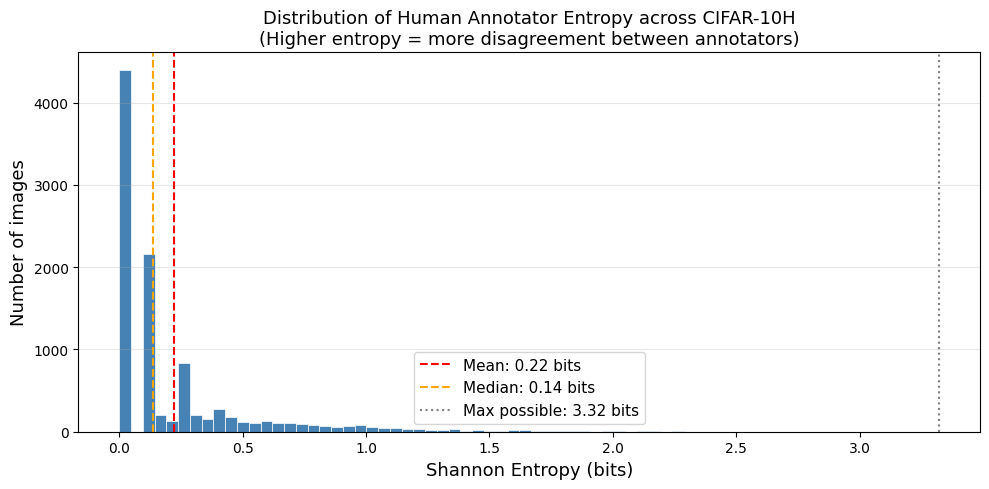

Saved to: /content/drive/MyDrive/cifar10h_project/results/viz1_entropy_histogram.png


In [15]:

# CELL 11 — Required Visualization 1: Entropy histogram

fig, ax = plt.subplots(figsize=(10, 5))


ax.hist(entropies, bins=60, color='steelblue', edgecolor='white', linewidth=0.5)


ax.axvline(x=entropies.mean(),   color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean: {entropies.mean():.2f} bits')
ax.axvline(x=np.median(entropies), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {np.median(entropies):.2f} bits')
ax.axvline(x=np.log2(10),        color='gray',   linestyle=':',  linewidth=1.5,
           label=f'Max possible: {np.log2(10):.2f} bits')

ax.set_xlabel('Shannon Entropy (bits)', fontsize=13)
ax.set_ylabel('Number of images', fontsize=13)
ax.set_title('Distribution of Human Annotator Entropy across CIFAR-10H\n'
             '(Higher entropy = more disagreement between annotators)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save to results folder on Drive
save_path = os.path.join(RESULTS_DIR, 'viz1_entropy_histogram.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

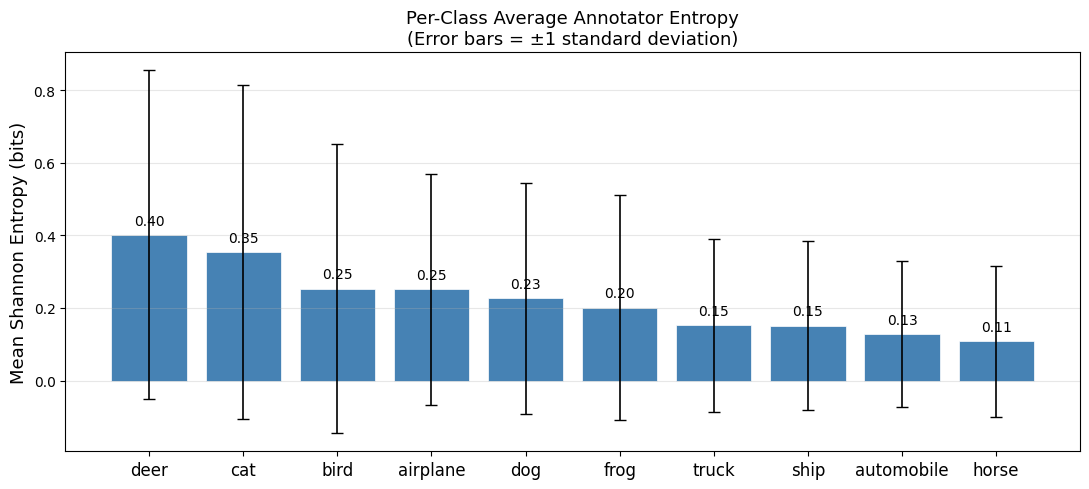

Saved to: /content/drive/MyDrive/cifar10h_project/results/viz2_per_class_entropy.png


In [16]:

# CELL 12 — Required Visualization 2: Per-class entropy
#This answers: "Which classes cause the most human disagreement?"

# Compute mean entropy per class
# We use the hard labels to group images by their "true" class
class_mean_entropy = []
class_std_entropy  = []

for class_idx in range(10):

    mask = (test_hard_labels == class_idx)
    class_entropies = entropies[mask]
    class_mean_entropy.append(class_entropies.mean())
    class_std_entropy.append(class_entropies.std())

class_mean_entropy = np.array(class_mean_entropy)
class_std_entropy  = np.array(class_std_entropy)


sorted_indices = np.argsort(class_mean_entropy)[::-1]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    range(10),
    class_mean_entropy[sorted_indices],
    yerr=class_std_entropy[sorted_indices],
    color='steelblue',
    edgecolor='white',
    linewidth=0.5,
    capsize=4,
    error_kw={'linewidth': 1.2}
)


ax.set_xticks(range(10))
ax.set_xticklabels([CLASS_NAMES[i] for i in sorted_indices], fontsize=12)
ax.set_ylabel('Mean Shannon Entropy (bits)', fontsize=13)
ax.set_title('Per-Class Average Annotator Entropy\n'
             '(Error bars = ±1 standard deviation)', fontsize=13)
ax.grid(axis='y', alpha=0.3)


for i, (bar, val) in enumerate(zip(bars, class_mean_entropy[sorted_indices])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'viz2_per_class_entropy.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

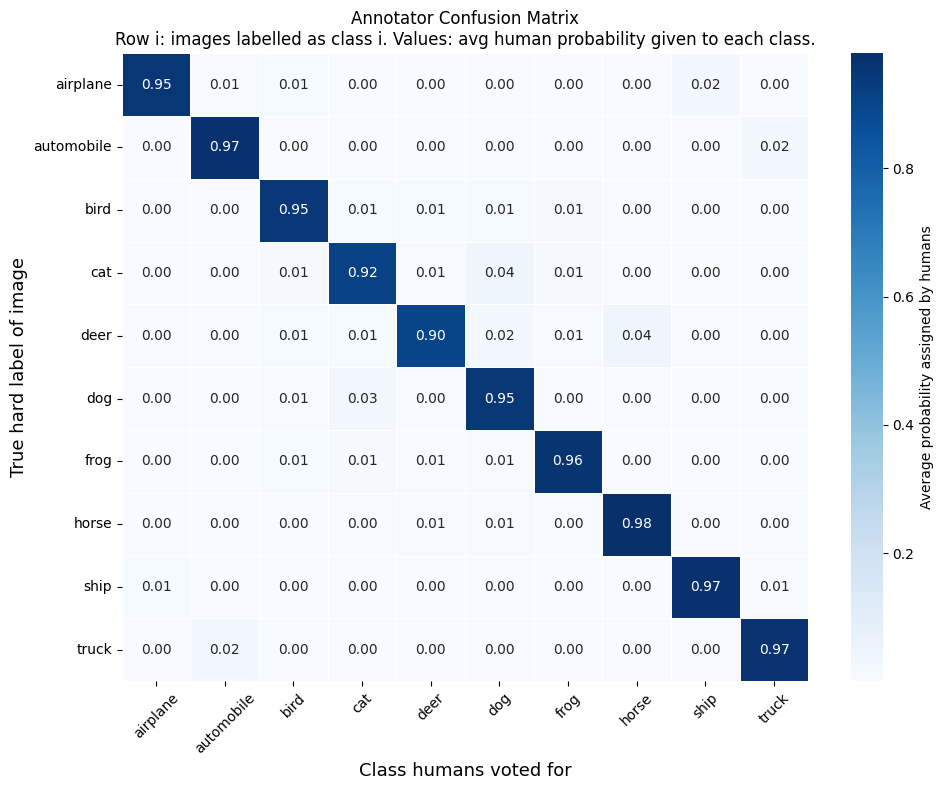

Saved to: /content/drive/MyDrive/cifar10h_project/results/viz3_annotator_confusion.png


In [17]:
# CELL 13 — Required Visualization 3: Annotator confusion matri
confusion = np.zeros((10, 10), dtype=np.float32)

for class_idx in range(10):

    mask = (test_hard_labels == class_idx)


    confusion[class_idx] = soft_labels[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    confusion,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    cbar_kws={'label': 'Average probability assigned by humans'},
    ax=ax
)

ax.set_xlabel('Class humans voted for', fontsize=13)
ax.set_ylabel('True hard label of image', fontsize=13)
ax.set_title('Annotator Confusion Matrix\n'
             'Row i: images labelled as class i. '
             'Values: avg human probability given to each class.', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'viz3_annotator_confusion.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

/tmp/ipykernel_5365/466277322.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


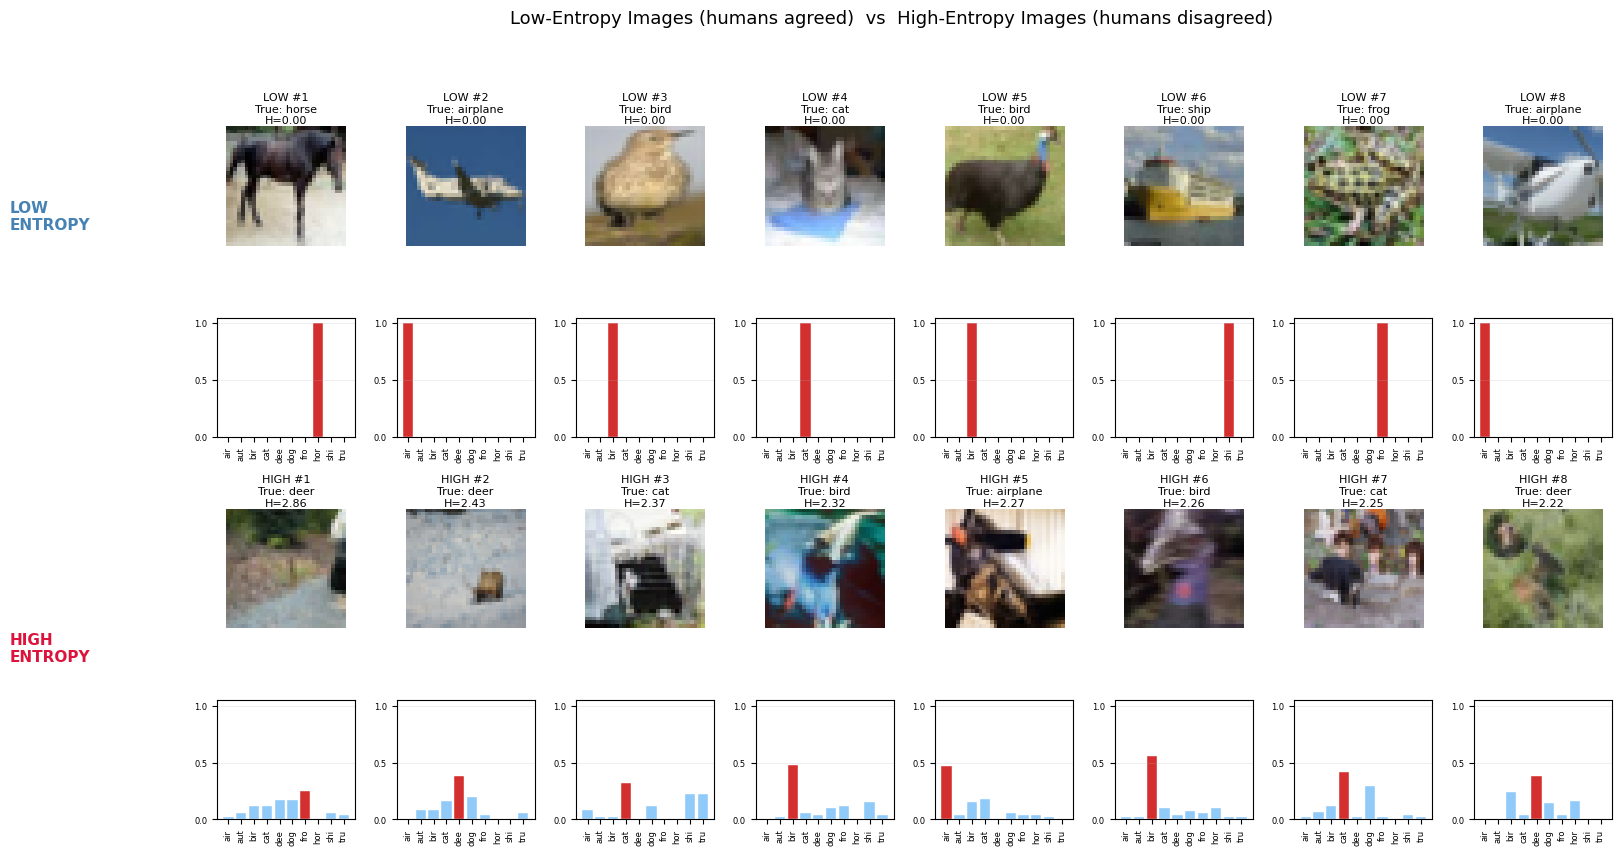

Saved to: /content/drive/MyDrive/cifar10h_project/results/viz4_low_vs_high_entropy_grid.png


In [18]:

# CELL 14 — Required Visualization 4: Example image grid

# Low entropy images: humans were unanimous → easy
# High entropy images: humans were split → genuinely ambiguous


def plot_image_with_distribution(ax_img, ax_bar, img_array, soft_dist,
                                  entropy_val, hard_label, title_prefix):
    """
    Helper function: plots one image (left) and its soft label
    distribution as a bar chart (right).

    img_array  : shape (3, 32, 32), float in [0, 1]
    soft_dist  : shape (10,), probability distribution
    entropy_val: float, precomputed entropy for this image
    hard_label : int, the majority-vote hard label
    """

    ax_img.imshow(np.transpose(img_array, (1, 2, 0)))
    ax_img.axis('off')
    ax_img.set_title(
        f'{title_prefix}\nTrue: {CLASS_NAMES[hard_label]}\nH={entropy_val:.2f}',
        fontsize=8, pad=2
    )


    colors = ['#d32f2f' if v == soft_dist.max() else '#90caf9' for v in soft_dist]
    ax_bar.bar(range(10), soft_dist, color=colors, edgecolor='white', linewidth=0.3)
    ax_bar.set_ylim(0, 1.05)
    ax_bar.set_xticks(range(10))
    ax_bar.set_xticklabels([c[:3] for c in CLASS_NAMES],
                            rotation=90, fontsize=6)
    ax_bar.set_yticks([0, 0.5, 1.0])
    ax_bar.tick_params(axis='y', labelsize=6)
    ax_bar.grid(axis='y', alpha=0.3, linewidth=0.5)



n_examples = 8
sorted_by_entropy = np.argsort(entropies)
low_entropy_indices  = sorted_by_entropy[:n_examples]    # 8 most certain
high_entropy_indices = sorted_by_entropy[-n_examples:][::-1]  # 8 most ambiguous


fig = plt.figure(figsize=(18, 9))
fig.suptitle('Low-Entropy Images (humans agreed)  vs  '
             'High-Entropy Images (humans disagreed)',
             fontsize=13, y=1.01)

gs = gridspec.GridSpec(4, n_examples, figure=fig,
                       hspace=0.6, wspace=0.3)


for col, idx in enumerate(low_entropy_indices):
    ax_img = fig.add_subplot(gs[0, col])
    ax_bar = fig.add_subplot(gs[1, col])
    plot_image_with_distribution(
        ax_img, ax_bar,
        img_array   = test_images[idx],
        soft_dist   = soft_labels[idx],
        entropy_val = entropies[idx],
        hard_label  = test_hard_labels[idx],
        title_prefix= f'LOW #{col+1}'
    )


fig.text(0.01, 0.78, 'LOW\nENTROPY', va='center', ha='left',
         fontsize=11, color='steelblue', fontweight='bold')
fig.text(0.01, 0.30, 'HIGH\nENTROPY', va='center', ha='left',
         fontsize=11, color='crimson', fontweight='bold')


for col, idx in enumerate(high_entropy_indices):
    ax_img = fig.add_subplot(gs[2, col])
    ax_bar = fig.add_subplot(gs[3, col])
    plot_image_with_distribution(
        ax_img, ax_bar,
        img_array   = test_images[idx],
        soft_dist   = soft_labels[idx],
        entropy_val = entropies[idx],
        hard_label  = test_hard_labels[idx],
        title_prefix= f'HIGH #{col+1}'
    )

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'viz4_low_vs_high_entropy_grid.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

In [20]:

# CELL 15 — Final summary and file checklist



print("NB1 COMPLETE — FILE CHECKLIST")


files_to_check = {
    "CIFAR-10H soft labels"    : CIFAR10H_PATH,
    "Entropy array"            : ENTROPY_PATH,
    "Split indices"            : SPLIT_PATH,
    "Viz 1: entropy histogram" : os.path.join(RESULTS_DIR, 'viz1_entropy_histogram.png'),
    "Viz 2: per-class entropy" : os.path.join(RESULTS_DIR, 'viz2_per_class_entropy.png'),
    "Viz 3: confusion matrix"  : os.path.join(RESULTS_DIR, 'viz3_annotator_confusion.png'),
    "Viz 4: image grid"        : os.path.join(RESULTS_DIR, 'viz4_low_vs_high_entropy_grid.png'),
}

all_ok = True
for name, path in files_to_check.items():
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    size   = f"({os.path.getsize(path)/1024:.1f} KB)" if exists else ""
    print(f"  {'OK' if exists else '!!'} {name:<30} {size}")
    if not exists:
        all_ok = False

if all_ok:
    print("All files present. NB1 is complete.")

else:
    print("Some files are missing. Re-run the relevant cells.")


split_data = np.load(SPLIT_PATH)
print(f"\nSplit summary (seed={SEED}):")
print(f"  Train : {len(split_data['train_indices']):,} images")
print(f"  Val   : {len(split_data['val_indices']):,} images")
print(f"  Test  : {len(split_data['test_indices']):,} images")

NB1 COMPLETE — FILE CHECKLIST
  OK CIFAR-10H soft labels          (781.4 KB)
  OK Entropy array                  (78.2 KB)
  OK Split indices                  (79.1 KB)
  OK Viz 1: entropy histogram       (71.9 KB)
  OK Viz 2: per-class entropy       (58.3 KB)
  OK Viz 3: confusion matrix        (136.2 KB)
  OK Viz 4: image grid              (142.1 KB)
All files present. NB1 is complete.

Split summary (seed=42):
  Train : 6,000 images
  Val   : 2,000 images
  Test  : 2,000 images
